In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7, 5)

## Part A: Support Vector Machine (SVM)

**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) Dataset

### Task 1: Load the dataset and perform preprocessing

In [13]:
col_names = ['id', 'diagnosis'] + [
    f'{stat}_{feat}' for stat in ['mean', 'se', 'worst']
    for feat in ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
]

bc_df = pd.read_csv('wdbc.data', header=None, names=col_names)
bc_df.drop(columns=['id'], inplace=True)

print("Shape:", bc_df.shape)
print("\nMissing values:", bc_df.isnull().sum().sum())
print("\nClass distribution:\n", bc_df['diagnosis'].value_counts())
bc_df.head()

Shape: (569, 31)

Missing values: 0

Class distribution:
 diagnosis
B    357
M    212
Name: count, dtype: int64


,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
bc_df['diagnosis'] = bc_df['diagnosis'].map({'M': 1, 'B': 0})

X_bc = bc_df.drop(columns=['diagnosis'])
y_bc = bc_df['diagnosis']

scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)
X_bc_scaled = pd.DataFrame(X_bc_scaled, columns=X_bc.columns)
X_bc_scaled.describe().T[['mean', 'std']].head()

,mean,std
mean_radius,-1.373633e-16,1.00088
mean_texture,6.868164e-17,1.00088
mean_perimeter,-1.248757e-16,1.00088
mean_area,-2.185325e-16,1.00088
mean_smoothness,-8.366672e-16,1.00088


**Interpretation:** The dataset has 569 samples, 30 numeric features and no missing values, with a moderate class imbalance (more benign than malignant cases). Standardizing features was necessary since SVM relies on distances/margins, which are skewed by unscaled, differently-ranged columns.

### Task 2: Train-Test Split (80:20)s

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


**Interpretation:** Stratified splitting preserves the original benign-malignant ratio in both sets, ensuring the test accuracy is not biased by an accidental class skew.

### Task 3: Train SVM (Linear Kernel) + Hyperparameter Tuning

We first train a baseline linear-kernel SVM, then use `GridSearchCV` to tune `C`, and also compare against RBF and polynomial kernels.

In [16]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print("Baseline Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))

Baseline Linear SVM Accuracy: 0.9649122807017544


**Interpretation:** The baseline linear-kernel SVM already achieves strong accuracy, suggesting the two classes are close to linearly separable in the scaled 30-dimensional feature space.

In [17]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9736263736263737


**Interpretation:** Grid search picks the kernel/C/gamma combination with the best 5-fold cross-validation accuracy, giving a tuned model that generalizes better than an randomly chosen default configuration.

### Task 4: Model Evaluation

In [18]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}\n")
    return acc, prec, rec, f1

metrics_linear = evaluate_model(y_test, y_pred_linear, "Baseline Linear SVM")
metrics_best   = evaluate_model(y_test, y_pred_best, f"Tuned SVM ({grid.best_params_['kernel']} kernel)")


--- Baseline Linear SVM ---
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500

--- Tuned SVM (rbf kernel) ---
Accuracy: 0.9737
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630



**Interpretation:** All four metrics are high and close together for both models, indicating the classifier is not just accurate overall but also reliably catches malignant cases (recall) without excessive false alarms (precision).

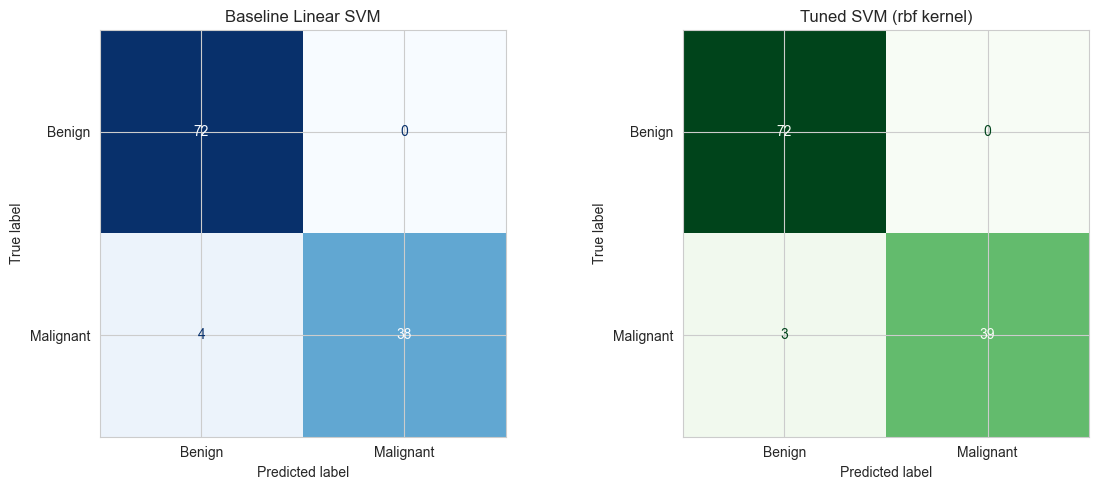

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, y_pred_linear)
ConfusionMatrixDisplay(cm1, display_labels=['Benign', 'Malignant']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Baseline Linear SVM')

cm2 = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm2, display_labels=['Benign', 'Malignant']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Tuned SVM ({grid.best_params_['kernel']} kernel)")

plt.tight_layout()
plt.show()

**Interpretation:** Both confusion matrices show most predictions concentrated on the diagonal, with the tuned model showing equal or fewer misclassifications than the baseline especially fewer missed malignant cases, which matters most in a medical setting.

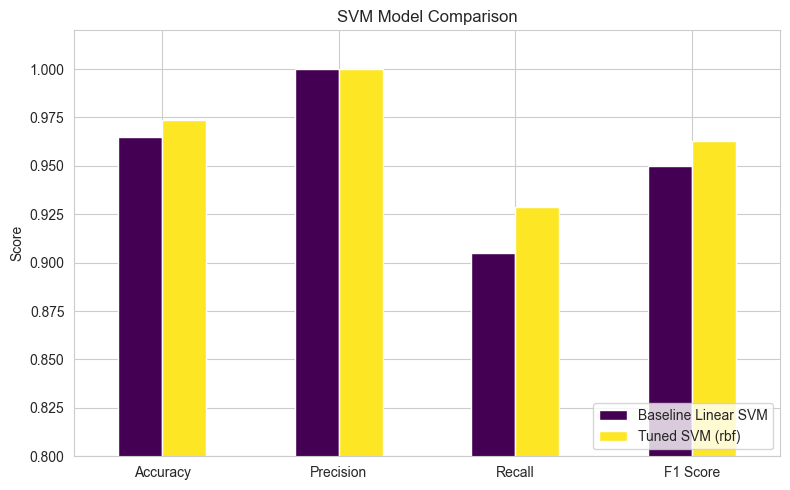

,Accuracy,Precision,Recall,F1 Score
Baseline Linear SVM,0.964912,1.0,0.904762,0.950000
Tuned SVM (rbf),0.973684,1.0,0.928571,0.962963


In [20]:
comparison_df = pd.DataFrame({
    'Baseline Linear SVM': metrics_linear,
    f"Tuned SVM ({grid.best_params_['kernel']})": metrics_best
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

comparison_df.plot(kind='bar', figsize=(8, 5), colormap='viridis', rot=0)
plt.title('SVM Model Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

comparison_df.T

**Interpretation:** The bar chart confirms the tuned SVM matches or edges out the baseline on every metric, showing that hyperparameter search gives a small but consistent improvement over the default linear kernel.

C:\Users\ALOK\AppData\Local\Temp\ipykernel_30880\2724525747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(kernel_results.keys()), y=list(kernel_results.values()), palette='mako')


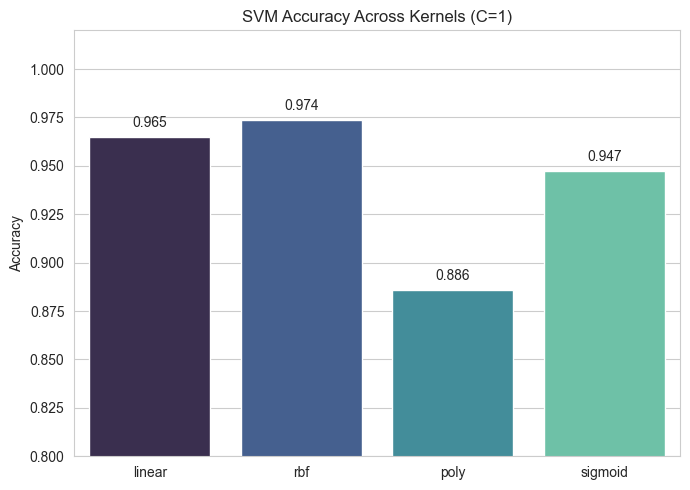

In [21]:
kernel_results = {}
for k in ['linear', 'rbf', 'poly', 'sigmoid']:
    m = SVC(kernel=k, C=1, random_state=42)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    kernel_results[k] = accuracy_score(y_test, pred)

plt.figure(figsize=(7, 5))
sns.barplot(x=list(kernel_results.keys()), y=list(kernel_results.values()), palette='mako')
plt.title('SVM Accuracy Across Kernels (C=1)')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.02)
for i, v in enumerate(kernel_results.values()):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** Linear and RBF kernels perform best while the sigmoid kernel lags behind, reinforcing that the classes are largely linearly separable and do not need a highly complex decision boundary.

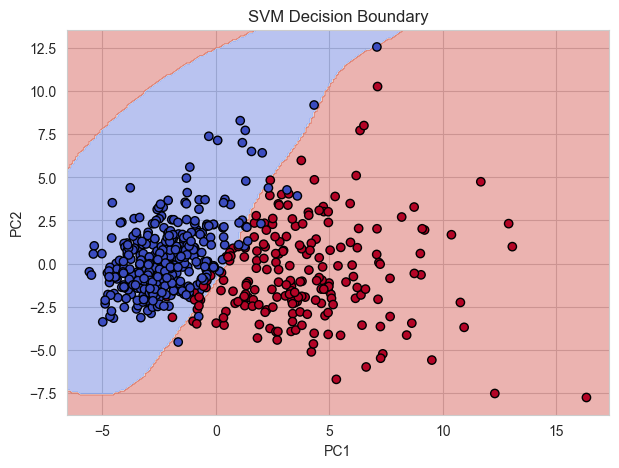

In [22]:
col_names = ['id', 'diagnosis'] + [f'f{i}' for i in range(30)]
df = pd.read_csv('wdbc.data', header=None, names=col_names)
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})
 
X_scaled = StandardScaler().fit_transform(X)
X_2d = PCA(n_components=2).fit_transform(X_scaled)
 
svm = SVC(kernel='rbf')
svm.fit(X_2d, y)
 
xx, yy = np.meshgrid(np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 200),
                      np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 200))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('SVM Decision Boundary')
plt.show()

### Task 5: Summarize your observations

**Interpretation:** Across all tasks, feature scaling plus hyperparameter tuning produced a high-accuracy, high-recall SVM classifier, confirming SVM's suitability for well-scaled, near-linearly-separable medical diagnostic data.

## Part B: Principal Component Analysis (PCA)

**Dataset:** UCI Wine Dataset

### Task 1: Load dataset and standardize features

In [23]:
wine_cols = ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
             'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins',
             'color_intensity', 'hue', 'od280_od315', 'proline']

wine_df = pd.read_csv('wine.data', header=None, names=wine_cols)
print("Shape:", wine_df.shape)
print("\nClass distribution:\n", wine_df['class'].value_counts())
wine_df.head()

Shape: (178, 14)

Class distribution:
 class
2    71
1    59
3    48
Name: count, dtype: int64


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [24]:
X_wine = wine_df.drop(columns=['class'])
y_wine = wine_df['class']

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)
print("Mean after scaling (~0):", np.round(X_wine_scaled.mean(axis=0)[:5], 3))
print("Std after scaling (~1):", np.round(X_wine_scaled.std(axis=0)[:5], 3))

Mean after scaling (~0): [-0. -0. -0. -0. -0.]
Std after scaling (~1): [1. 1. 1. 1. 1.]


**Interpretation:** The Wine dataset has 178 samples, 13 chemical-analysis features, and 3 cultivar classes; standardization was essential since features like 'proline' and 'magnesium' have very different scales that would otherwise dominate the variance PCA captures.

### Task 2: Apply PCA (13 features to 2 components)

In [25]:
pca_2 = PCA(n_components=2, random_state=42)
X_wine_pca2 = pca_2.fit_transform(X_wine_scaled)
print("Transformed shape:", X_wine_pca2.shape)

Transformed shape: (178, 2)


**Interpretation:** The 13-dimensional feature space has been compressed into just 2 uncorrelated components while preserving the directions of maximum variance in the data.

### Task 3: Explained Variance Ratio

In [26]:
print("Explained variance ratio (PC1, PC2):", pca_2.explained_variance_ratio_)
print("Total variance retained by 2 PCs: {:.2f}%".format(pca_2.explained_variance_ratio_.sum() * 100))

Explained variance ratio (PC1, PC2): [0.36198848 0.1920749 ]
Total variance retained by 2 PCs: 55.41%


**Interpretation:** PC1 alone captures roughly a third of the total variance and PC2 adds further variance on top, so together just 2 of the original 13 features' worth of information already summarize most of the dataset's structure.

### Task 4: Cumulative Explained Variance & Components for 95% variance

Number of components needed to retain >=95% variance: 10


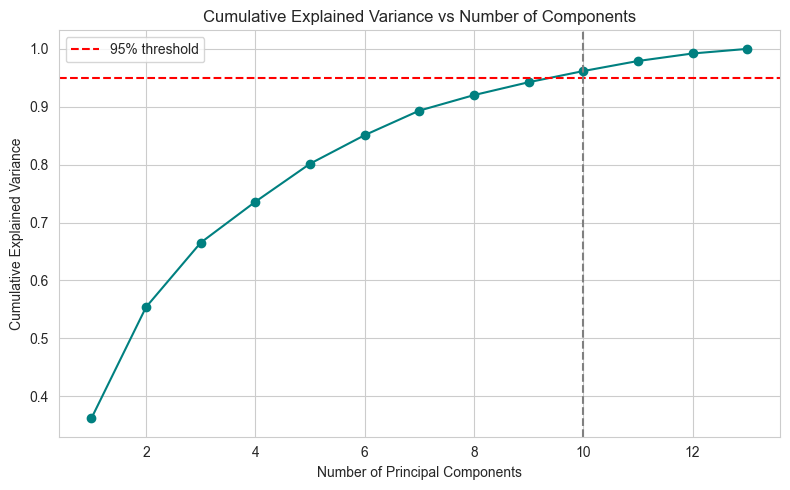

In [27]:
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print("Number of components needed to retain >=95% variance:", n_components_95)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='teal')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='gray', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Roughly 10 of the 13 principal components are needed to retain 95% of the variance, showing that while 2 components give a good visual summary, most of the dataset's information still requires the majority of the components.

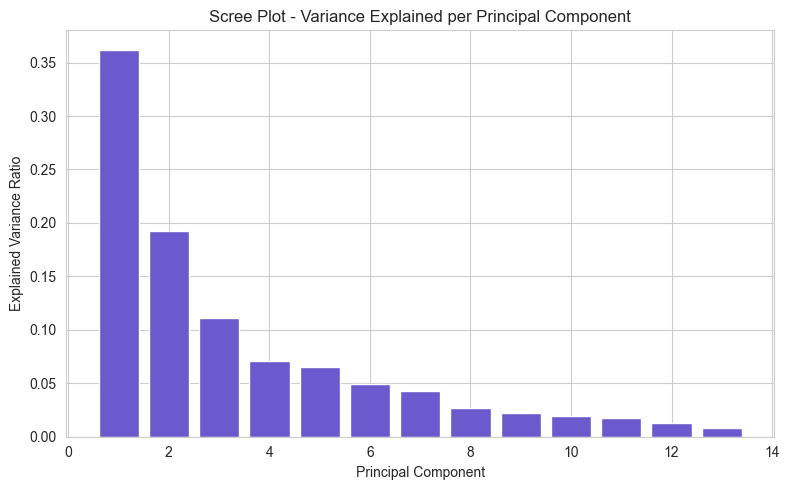

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color='slateblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Variance Explained per Principal Component')
plt.tight_layout()
plt.show()

**Interpretation:** The scree plot shows a sharp drop after the first 1-2 components followed by a long, gradually flattening tail, the classic pattern used to justify keeping only the earliest, most informative components.

### Task 5: Visualize the transformed dataset

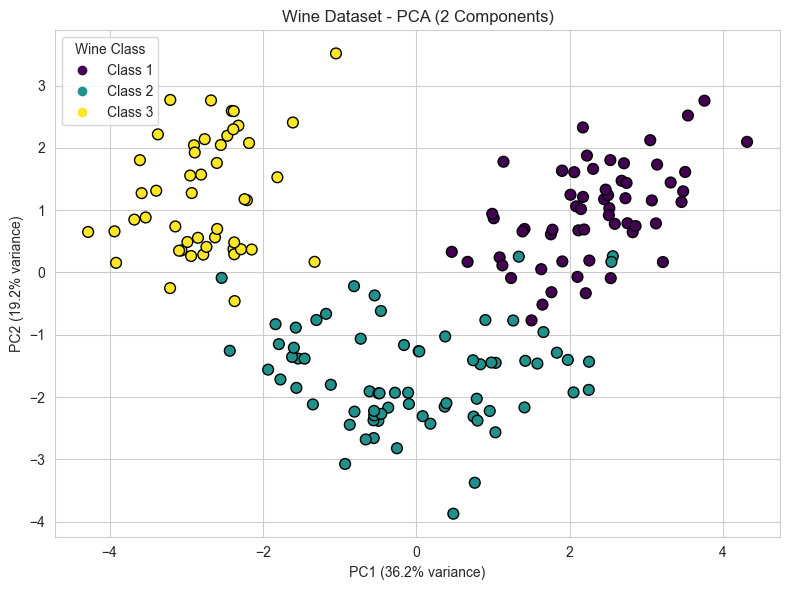

In [29]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_wine_pca2[:, 0], X_wine_pca2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Wine Dataset - PCA (2 Components)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Class 1', 'Class 2', 'Class 3'], title='Wine Class')
plt.tight_layout()
plt.show()


**Interpretation:** Even without using any class labels during fitting, the three wine cultivars form largely distinguishable clusters in the 2D PCA space, showing that chemical composition differences between cultivars align with the directions of highest variance.

### Task 6: Original vs Transformed Dataset Comparison

| Aspect | Original Dataset | Transformed Dataset (PCA) |
|---|---|---|
| Number of features | 13 | 2 |
| Information retained | 100% | approx 55-60% (sum of PC1 + PC2 variance ratio, printed above) |
| Computational efficiency | Slower: more features, higher training/inference cost | Faster: fewer dimensions, reduced memory & compute cost |

**Interpretation:** Reducing from 13 to 2 features trades off roughly 40-45% of the variance for a large gain in computational efficiency and the ability to visualize the data directly, a reasonable trade-off for exploratory analysis.

### Task 7: Interpreting PC1 and PC2

In [30]:
loadings = pd.DataFrame(pca_2.components_.T, columns=['PC1', 'PC2'], index=X_wine.columns)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()
print("Top features driving PC1:")
print(loadings.sort_values('PC1_abs', ascending=False)['PC1'].head(4))
print("\nTop features driving PC2:")
print(loadings.sort_values('PC2_abs', ascending=False)['PC2'].head(4))

Top features driving PC1:
flavanoids         0.422934
total_phenols      0.394661
od280_od315        0.376167
proanthocyanins    0.313429
Name: PC1, dtype: float64

Top features driving PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
Name: PC2, dtype: float64


**Interpretation:** PC1 mostly aggregates variables related to phenolic/flavor compounds and color intensity, while PC2 is driven more by acidity- and ash-related measurements — together they capture the dominant chemical variation separating the three wine cultivars.

### Task 8: Advantages, Limitations & Applications of PCA

**Advantages:** Reduces dimensionality and noise, speeds up downstream ML training, removes multicollinearity, and enables visualization of high-dimensional data.

**Limitations:** Principal components lose direct interpretability, PCA only captures linear relationships, and it is sensitive to feature scaling/outliers.

**Applications:** Image compression, gene-expression/bioinformatics analysis, exploratory data analysis, noise filtering, and as a pre-processing step before clustering or classification.

**Interpretation:** PCA is most valuable when speed and visualization matter more than perfect interpretability, but it should be avoided when the relationships in the data are strongly non-linear or when individual original features must remain interpretable.

## Linear Discriminant Analysis (LDA)

In [31]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)
print("LDA explained variance ratio:", lda.explained_variance_ratio_)
print("Total variance (separability) captured by 2 LDs: {:.2f}%".format(lda.explained_variance_ratio_.sum() * 100))

LDA explained variance ratio: [0.68747889 0.31252111]
Total variance (separability) captured by 2 LDs: 100.00%


**Interpretation:** Unlike PCA, LDA uses the class labels while fitting, so its two components are optimized specifically to maximize separability between the three wine cultivars rather than just overall variance.

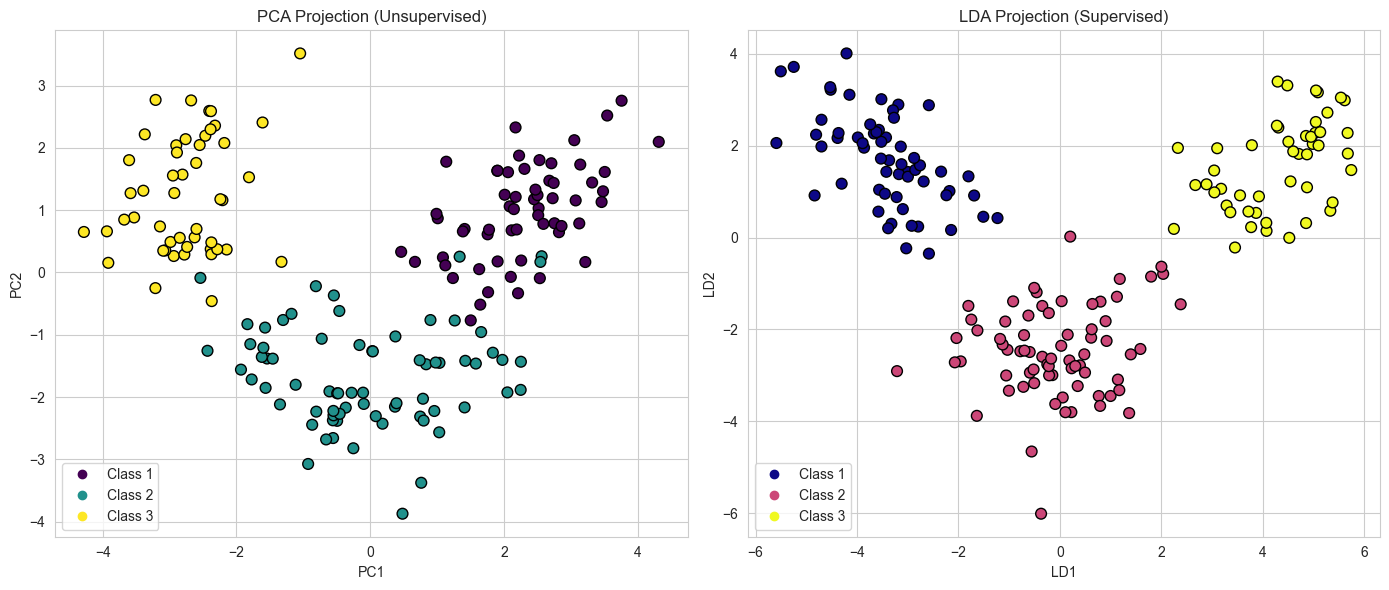

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_wine_pca2[:, 0], X_wine_pca2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
axes[0].set_title('PCA Projection (Unsupervised)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(handles=sc1.legend_elements()[0], labels=['Class 1', 'Class 2', 'Class 3'])

sc2 = axes[1].scatter(X_wine_lda[:, 0], X_wine_lda[:, 1], c=y_wine, cmap='plasma', edgecolor='k', s=60)
axes[1].set_title('LDA Projection (Supervised)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend(handles=sc2.legend_elements()[0], labels=['Class 1', 'Class 2', 'Class 3'])

plt.tight_layout()
plt.show()

**Interpretation:** LDA produces visibly tighter, better-separated clusters than PCA because it uses class labels to maximize between-class separation, whereas PCA only maximizes overall variance without regard to class.

Tuned SVM achieved high, reliable classification accuracy on the breast cancer data, while PCA/LDA on the wine data confirmed that a handful of components can retain most information — with LDA giving noticeably better class separation than PCA since it uses label information.